In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
%matplotlib inline

In [2]:
df = pd.read_csv("canada_per_capita_income.csv")

In [3]:
df.columns
df.rename(columns={'per capita income (US$)': 'price'}, inplace=True)
df.columns

Index(['year', 'price'], dtype='str')

<Axes: >

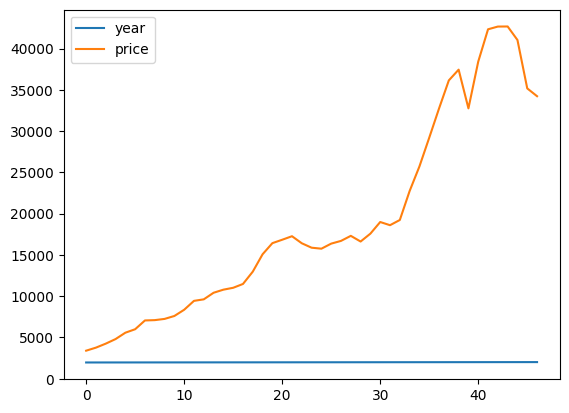

In [4]:
df.plot()

ValueError: x and y must be the same size

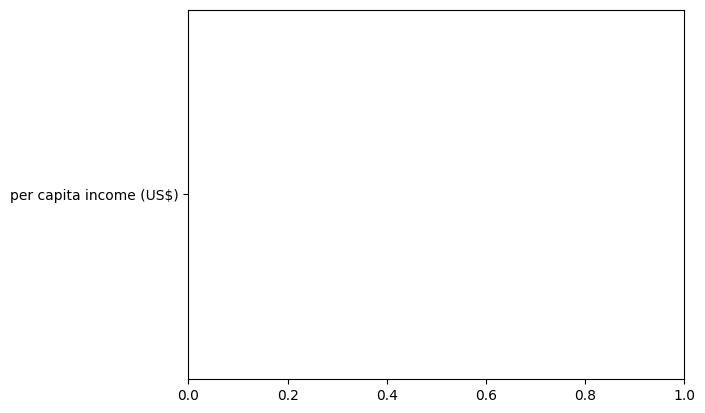

In [5]:
plt.scatter(x= 'year', y = 'per capita income (US$)', data= df)

In [ ]:
# it's suitable for linear model so le'ts go with that
reg = linear_model.LinearRegression()
reg.fit(df[["year"]], df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
reg.predict([[2030]])

/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([49573.34484664])

In [8]:
train_df = pd.read_csv("/home/kradarsh/Desktop/ML_core/projs/Comments Category Prediction/train_df.csv")
final_df = pd.read_csv("/home/kradarsh/Desktop/ML_core/projs/Comments Category Prediction/final_df.csv")

In [ ]:
train = final_df[]

In [9]:
x_ = train_df.drop(columns=['label'])
y_ = train_df['label'].astype(int).values
x_.shape, y_.shape

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_,
    y_,
    test_size=0.2,
    stratify=y_,
    random_state=42
)

In [10]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((158400, 34), (158400,), (39600, 34), (39600,))

In [11]:
train_df["post_id"].unique()
# finding post_label mean from x_train
post_stats = X_train.assign(label= y_train).groupby("post_id")['label'].agg(post_mean = 'mean', post_std = "std")
# mapping the label mean found from train to val and test
post_stats.reset_index().set_index("post_id")


,post_mean,post_std
post_id,,
20,2.000000,NaN
24,0.665904,0.917217
31,0.784869,0.980341
39,0.833023,1.012780
40,0.634881,0.929709
42,0.750000,1.035098
43,0.500000,0.925820
50,0.666667,0.984732
61,0.796499,1.026563


In [12]:
# X_train["post_mean"] = X_train["post_id"].map(post_stats["post_mean"])
# X_train["post_std"] = X_train["post_id"].map(post_stats["post_std"])

for data in [X_train, X_val]:
    data["post_mean"] = data["post_id"].map(post_stats["post_mean"])
    data["post_std"] = data["post_id"].map(post_stats["post_std"]).fillna(0.0)
# X_train[["post_id", 'post_mean',"post_std"]].groupby("post_id").value_counts()

In [13]:
final_df[final_df["gender"]=="transgender"]["post_id"].count()

np.int64(921)

In [14]:
(final_df['gender'] == 'transgender').astype(int).value_counts()

gender
0    299079
1       921
Name: count, dtype: int64

In [15]:
text = "She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals."

In [ ]:
upper_words = sum([1 for i in text if i[0].isupper()])
total = max(1, len(text))
text.count(r'[A-Z]')
# upper_words
# final_df["comment"].apply()

0

In [33]:
train_df["avg_words"] = train_df["comment_len"] /(train_df["word_cnt"]+1)

In [167]:
final_df["is_upper"] = final_df["comment"].str.count(r'[A-Z]')

In [173]:
total_letters = final_df['comment'].str.count(r'[a-zA-Z]')

# 3. Calculate ratio, replacing 0 with 1 to avoid division by zero
final_df['uppercase_ratio'] = final_df["is_upper"] / total_letters.replace(0, 1)


In [175]:
final_df.columns

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2',
       'race', 'religion', 'gender', 'disability', 'comment', 'label',
       'is_train', 'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'comment_len', 'word_cnt',
       'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1', 'engagement_score', 'emoticon_density',
       'post_comments_count', 'is_upper', 'uppercase_ratio'],
      dtype='str')

In [177]:
final_df["very_long_comment"] = (final_df["comment_len"]>990).astype(int)

In [20]:
import seaborn as sns

<Axes: xlabel='label', ylabel='if_1_log'>

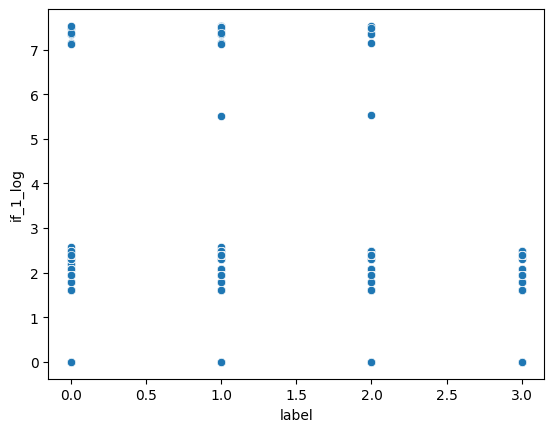

In [35]:
sns.scatterplot(data = train_df, x = "label", y="if_1_log")

<Axes: xlabel='label', ylabel='if_2_log'>

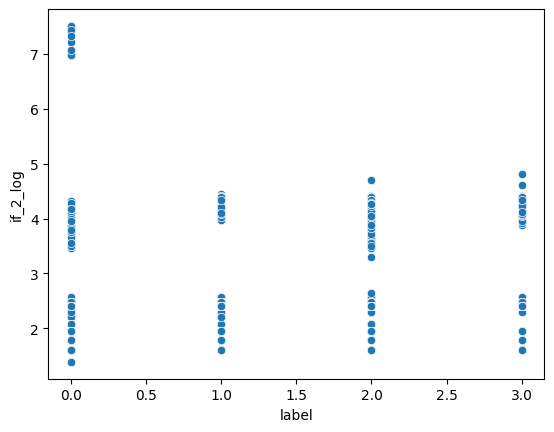

In [36]:
sns.scatterplot(data = train_df, x = "label", y="if_2_log")

In [37]:
train_df.columns

Index(['Unnamed: 0', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment',
       'label', 'is_train', 'weekday', 'weekend', 'created_hour',
       'race_missing', 'religion_missing', 'gender_missing', 'comment_len',
       'word_cnt', 'num_!', 'num_ques', 'emoji_counts', 'votes_ratio',
       'upvote_log1', 'downvote_log1', 'engagement_score', 'emoticon_density',
       'post_comments_count', 'if_1_log', 'if_2_log', 'if_interaction_log',
       'sentiment_vader', 'avg_words'],
      dtype='str')

<Axes: >

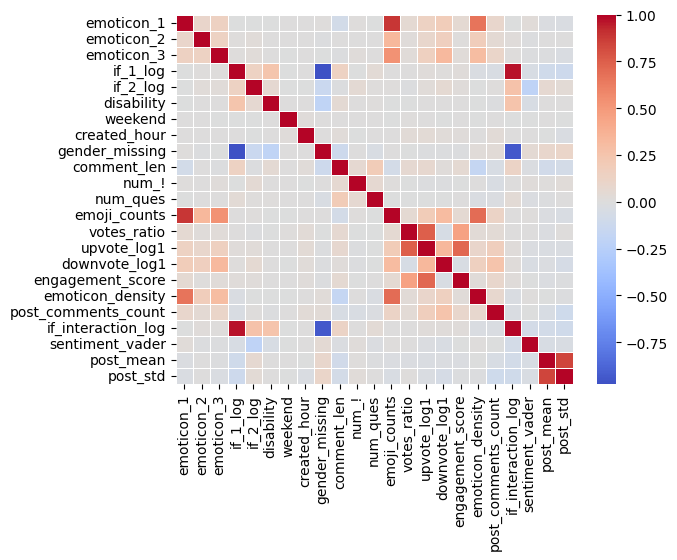

In [39]:
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_1_log','if_2_log','disability', 'weekend', 'created_hour',
                'gender_missing', 'comment_len',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log',
                'sentiment_vader', 'post_mean', 'post_std'] #excluded: ['post_id', 'comments'(in tf-idf), word_cnt,'race_missing', 'religion_missing', 'if_1', 'if_2', 'if_1_log']

corr = X_train[numerical_col].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)